In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

In [3]:
X_test = pd.read_csv("../dataset/X_test.csv")
y_test = pd.read_csv("../dataset/y_test.csv").squeeze()

In [4]:
log_reg = joblib.load("../dataset/logistic_regression.pkl")
decision_tree = joblib.load("../dataset/decision_tree.pkl")
random_forest = joblib.load("../dataset/random_forest.pkl")

In [5]:
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [6]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.886610,0.429494,0.905497,0.582634,0.96391
1,Decision Tree,0.999985,0.999943,0.999886,0.999914,0.99994
2,Random Forest,0.999975,1.000000,0.999714,0.999857,1.00000


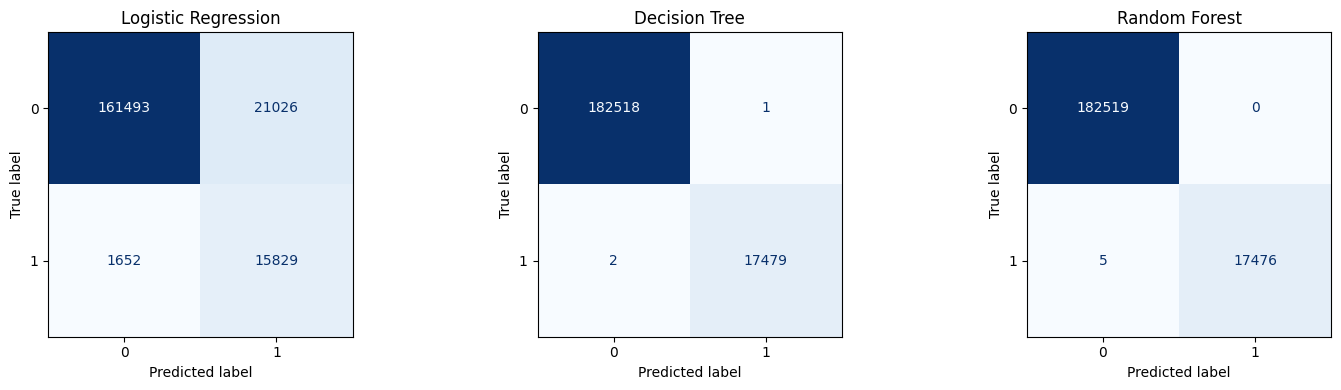

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr)
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt)
).plot(ax=axes[1], cmap="Blues", colorbar=False)

axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf)
).plot(ax=axes[2], cmap="Blues", colorbar=False)

axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

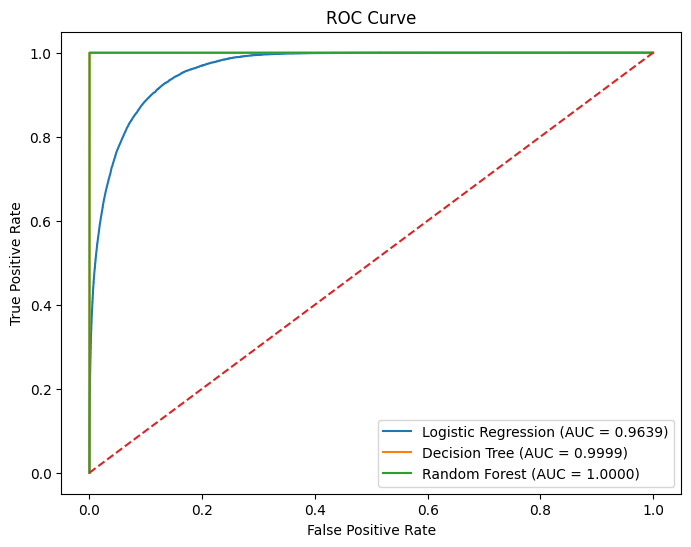

In [8]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.4f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

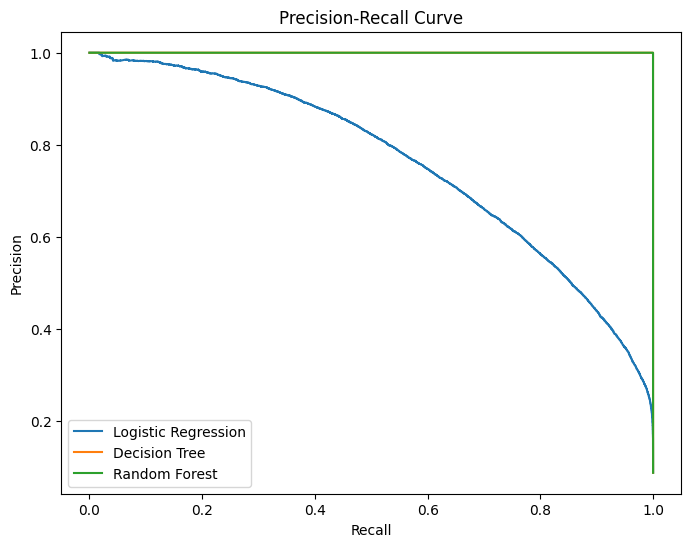

In [9]:
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test, y_prob_lr
)

precision_dt, recall_dt, _ = precision_recall_curve(
    y_test, y_prob_dt
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_dt,
    precision_dt,
    label="Decision Tree"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [11]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred = (y_prob_rf >= threshold).astype(int)

    print(
        "Threshold:", threshold,
        "Precision:", round(precision_score(y_test, y_pred), 4),
        "Recall:", round(recall_score(y_test, y_pred), 4),
        "F1:", round(f1_score(y_test, y_pred), 4)
    )

Threshold: 0.1 Precision: 0.977 Recall: 1.0 F1: 0.9884
Threshold: 0.2 Precision: 0.9998 Recall: 0.9999 F1: 0.9999
Threshold: 0.3 Precision: 0.9999 Recall: 0.9999 F1: 0.9999
Threshold: 0.4 Precision: 1.0 Recall: 0.9998 F1: 0.9999
Threshold: 0.5 Precision: 1.0 Recall: 0.9997 F1: 0.9999
Threshold: 0.6 Precision: 1.0 Recall: 0.9996 F1: 0.9998
Threshold: 0.7 Precision: 1.0 Recall: 0.9994 F1: 0.9997
Threshold: 0.8 Precision: 1.0 Recall: 0.9989 F1: 0.9995
Threshold: 0.9 Precision: 1.0 Recall: 0.9958 F1: 0.9979


In [12]:
thresholds = np.arange(0.1, 1.0, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred = (y_prob_rf >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best threshold: 0.2899999999999999
Best F1 Score: 0.999942795034609


In [13]:
y_pred_best = (y_prob_rf >= best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.99999
Precision: 0.999942795034609
Recall: 0.999942795034609
F1 Score: 0.999942795034609

Confusion Matrix:
[[182518      1]
 [     1  17480]]


In [14]:
results.to_csv("../dataset/model_comparison.csv", index=False)